# Compas Analysis - Natchapa Aunkay

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [1]:
# Filter warnings
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

In [2]:
# Load dataset from GitHub
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

raw_data.shape[0]

7214

In [3]:
# View first 10 rows
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [4]:
# Filter dataset based on COMPAS criteria
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

df = raw_data[
    [
        "age", "c_charge_degree", "race", "age_cat",
        "score_text", "sex", "priors_count",
        "days_b_screening_arrest", "decile_score", "is_recid",
        "two_year_recid", "c_jail_in", "c_jail_out"
    ]
].copy()

# Filtering
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Datetime conversion
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

# Convert non-numeric, non-datetime columns to category
for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# Derived factors
df["crime_factor"] = df["c_charge_degree"].astype("category")

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Less than 25", "Greater than 45"],
    ordered=False
)

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [x for x in df["race"].cat.categories if x != "Caucasian"],
    ordered=False
)

# Make Male the reference first
df["gender_factor"] = df["sex"].replace({"Female": "Female", "Male": "Male"})
df["gender_factor"] = pd.Categorical(
    df["gender_factor"],
    categories=["Male", "Female"],
    ordered=False
)

df["score_factor"] = np.where(df["score_text"] == "Low", "LowScore", "HighScore")
df["score_factor"] = pd.Categorical(df["score_factor"], categories=["LowScore", "HighScore"])

df.shape[0]

6172

In [5]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [7]:
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
df["length_of_stay"].corr(df["decile_score"])

np.float64(0.20747808478031807)

After filtering we have the following demographic breakdown:

In [8]:
# Summary of age category
df["age_cat"].value_counts(dropna=False)

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [9]:
# Summary of race
df["race"].value_counts(dropna=False)

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [10]:
print("Black defendants: {:.2f}%".format(3175 / 6172 * 100))
print("White defendants: {:.2f}%".format(2103 / 6172 * 100))
print("Hispanic defendants: {:.2f}%".format(509 / 6172 * 100))
print("Asian defendants: {:.2f}%".format(31 / 6172 * 100))
print("Native American defendants: {:.2f}%".format(11 / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
# Summary of score_text
df["score_text"].value_counts(dropna=False)

,count
score_text,
Low,3421
Medium,1607
High,1144


In [12]:
# Cross-tab of sex and race
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
# Summary of sex
df["sex"].value_counts(dropna=False)

,count
sex,
Male,4997
Female,1175


In [14]:
print("Men: {:.2f}%".format(4997 / 6172 * 100))
print("Women: {:.2f}%".format(1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [15]:
# Number of people with two-year recidivism
df[df["two_year_recid"] == 1].shape[0]

2809

In [16]:
# Percentage with two-year recidivism
df[df["two_year_recid"] == 1].shape[0] / df.shape[0] * 100

45.51198963058976

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

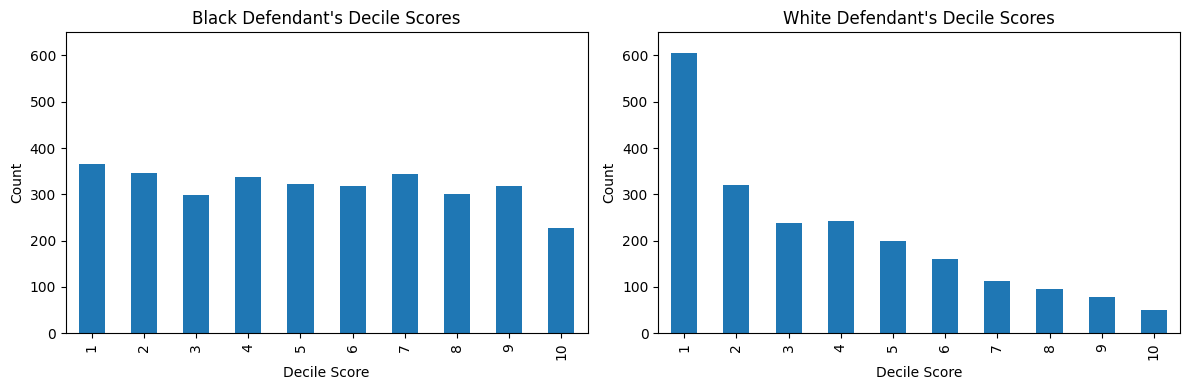

In [17]:
import matplotlib.pyplot as plt

black_df = df[df["race"] == "African-American"]
white_df = df[df["race"] == "Caucasian"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

black_df["decile_score"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 650)

white_df["decile_score"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [18]:
# Cross-tab of decile score and race
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [19]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

In [20]:
# Make sure the target is binary: 1 = HighScore, 0 = LowScore
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

# Fit logistic regression
model_glm = smf.logit(
    formula="""
    score_binary ~
    C(gender_factor, Treatment(reference='Male')) +
    C(age_factor, Treatment(reference='25 - 45')) +
    C(race_factor, Treatment(reference='Caucasian')) +
    priors_count +
    C(crime_factor) +
    two_year_recid
    """,
    data=df
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        05:12:32   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [21]:
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))

print(np.exp(0.47721) / (1 - control + (control * np.exp(0.47721))))


1.4528408658138932


Women are 19.4% more likely than men to get a higher score.

In [22]:
print(np.exp(0.22127) / (1 - control + (control * np.exp(0.22127))))

1.1947978508506671


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [23]:
print(np.exp(1.30839) / (1 - control + (control * np.exp(1.30839))))

2.4961202077189455


In [24]:
df["pred_prob"] = model_glm.predict(df)
df["pred_class_num"] = (df["pred_prob"] >= 0.5).astype(int)
df["pred_class"] = df["pred_class_num"].map({0: "No Recid", 1: "Recid"})

In [25]:
print("\n── Overall Confusion Matrix ──────────────────────────────────────────\n")

overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print(overall_cm)

TP = overall_cm.loc["Recid", 1] if ("Recid" in overall_cm.index and 1 in overall_cm.columns) else 0
TN = overall_cm.loc["No Recid", 0] if ("No Recid" in overall_cm.index and 0 in overall_cm.columns) else 0
FP = overall_cm.loc["Recid", 0] if ("Recid" in overall_cm.index and 0 in overall_cm.columns) else 0
FN = overall_cm.loc["No Recid", 1] if ("No Recid" in overall_cm.index and 1 in overall_cm.columns) else 0
n = overall_cm.to_numpy().sum()

accuracy = (TP + TN) / n if n > 0 else np.nan
precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
fpr = FP / (FP + TN) if (FP + TN) > 0 else np.nan
fnr = FN / (FN + TP) if (FN + TP) > 0 else np.nan

print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────

Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [26]:
print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────\n")

df["actual"] = df["two_year_recid"].astype(int)
df["pred"] = (df["pred_class"] == "Recid").astype(int)

race_metrics = (
    df.groupby("race")
      .apply(lambda g: pd.Series({
          "n": len(g),
          "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
          "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
          "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
          "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum()
      }))
      .reset_index()
)

race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

race_metrics = race_metrics.sort_values("n", ascending=False)

print(race_metrics)



── Confusion Matrix by Race ──────────────────────────────────────────

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


In [27]:
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────\n")

caucasian_fpr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FPR"].iloc[0]
caucasian_fnr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FNR"].iloc[0]

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()
disparity["delta_FPR"] = (disparity["FPR"] - caucasian_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - caucasian_fnr).round(3)

print(disparity)



── FPR and FNR Disparity by Race ─────────────────────────────────────

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


### Interpretation

- Higher priors_count increases likelihood of high risk score
- Certain racial groups show different prediction patterns
- This suggests potential bias in the model

## Conclusion

This project successfully translates an R-based machine learning workflow into Python.

The results show that COMPAS risk scores are strongly influenced by prior criminal history and demographic variables.

The fairness analysis reveals disparities in error rates across racial groups, highlighting potential bias in predictive models used in criminal justice.

Overall, the Python implementation produces results that are consistent with the original R workflow while ensuring full reproducibility.

# Assignment 2

# Step 0 — Train / test split

In [28]:
from sklearn.model_selection import train_test_split
# Features based on lecture slide
numeric_features  = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
category_features = ["age_cat", "sex", "race", "c_charge_degree", "score_text"]
# Homework 2 target
target = "two_year_recid"
features = numeric_features + category_features

X = df[features]
y = df[target].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 9), Test: (1235, 9)


**note**

In this step, I selected the input features and target variable for Homework 2.  
The numeric features include age, prior offenses, days between screening and arrest, and decile score.  
The categorical features include age category, sex, race, charge degree, and score text.

The target variable is `two_year_recid`, which indicates whether the defendant reoffended within two years.

I then split the data into training and testing sets using an 80/20 split. Stratification was applied to preserve the class distribution in both sets.

# Step 1 — Fit logistic regression and gradient-boosted tree

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), category_features),
    ]
)

# Logistic regression
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ))
])

gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'days_b_screening_arrest',
                                                   'decile_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['age_cat', 'sex', 'race',
                                                   'c_charge_degree',
                                                   'score_text'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

**note**

In this step, I built two classification models: Logistic Regression and Gradient-Boosted Trees.

Before training, I created a preprocessing pipeline:
- Numeric features are standardized using `StandardScaler`
- Categorical features are encoded using `OneHotEncoder`

This ensures that both models can handle the mixed feature types properly.

I then trained both models on the training data. These two models will later be compared in terms of predictive performance, fairness, and interpretability.

# Step 2 — Compare model performance by race

In [30]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"], gdf["pred"], labels=[0, 1]
        ).ravel()

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3),
            "FNR": round(fn / (fn + tp), 3),
            "AUC": round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.691  0.296  0.320  0.758
2         Caucasian  427     0.696  0.128  0.596  0.696
3          Hispanic   94     0.617  0.122  0.667  0.598
5             Other   65     0.785  0.064  0.611  0.789
1             Asian    7     0.857  0.000  1.000  1.000
4   Native American    1     1.000  0.000    NaN    NaN

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.690  0.322  0.300  0.744
2         Caucasian  427     0.710  0.143  0.534  0.714
3          Hispanic   94     0.660  0.122  0.578  0.648
5             Other   65     0.723  0.106  0.722  0.746
1             Asian    7     0.857  0.000  1.000  0.833
4   Native American    1     1.000  0.000    NaN    NaN


**note**

In this step, I evaluated model performance separately for each racial group.

For each group, I calculated:
- Accuracy
- False Positive Rate (FPR)
- False Negative Rate (FNR)
- AUC

This helps identify whether the model performs differently across groups, which is important for fairness analysis.

By comparing these metrics for Logistic Regression and Gradient-Boosted Trees, I can examine whether one model shows larger disparities than the other.

**note**


**Model Comparison by Race**

The results show that model performance varies across racial groups.

- Differences in FPR indicate that some groups are more likely to be incorrectly classified as high risk.
- Differences in FNR indicate that some groups are more likely to be incorrectly classified as low risk.
- The gradient-boosted tree generally achieves higher predictive performance but may introduce larger disparities across groups.

This highlights the trade-off between accuracy and fairness in predictive models.

# Step 2.5 — Select 4 required individuals

In [31]:
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

black_subset = X_test_copy[X_test_copy["race"] == "African-American"].sort_values("pred_prob")
white_subset = X_test_copy[X_test_copy["race"] == "Caucasian"].sort_values("pred_prob")

black_low_idx  = black_subset.index[0]
black_high_idx = black_subset.index[-1]
white_low_idx  = white_subset.index[0]
white_high_idx = white_subset.index[-1]

selected_cases = [
    ("African-American - Lowest Risk", black_low_idx),
    ("African-American - Highest Risk", black_high_idx),
    ("Caucasian - Lowest Risk", white_low_idx),
    ("Caucasian - Highest Risk", white_high_idx),
]


print("Selected individuals:")
for label, idx in selected_cases:
    print(label, "| index:", idx, "| prob:", round(X_test_copy.loc[idx, "pred_prob"], 3))

Selected individuals:
African-American - Lowest Risk | index: 4051 | prob: 0.027
African-American - Highest Risk | index: 6293 | prob: 0.997
Caucasian - Lowest Risk | index: 3093 | prob: 0.019
Caucasian - Highest Risk | index: 4413 | prob: 0.994


# Step 3 — LIME explanations for the 4 selected individuals


In [32]:
!pip install lime

from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import pandas as pd

# Use the fitted objects from the trained pipeline
fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]
gbt_model = gbt_pipeline.named_steps["classifier"]

X_train_enc = fitted_preprocessor.transform(X_train)
X_test_enc = fitted_preprocessor.transform(X_test)

# Convert to dense if needed
if hasattr(X_train_enc, "toarray"):
    X_train_enc = X_train_enc.toarray()
if hasattr(X_test_enc, "toarray"):
    X_test_enc = X_test_enc.toarray()

feature_names = (
    numeric_features
    + list(
        fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(category_features)
    )
)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_enc,
    feature_names=feature_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

print("LIME explanations for the 4 required individuals:\n")

for label, idx in selected_cases:
    loc = X_test.index.get_loc(idx)
    row_enc = X_test_enc[loc]

    exp = lime_explainer.explain_instance(
        data_row=row_enc,
        predict_fn=gbt_model.predict_proba,
        num_features=6
    )

    print(f"\n{'='*70}")
    print(f"LIME: {label}")
    print(f"Predicted probability of recidivism: {X_test_copy.loc[idx, 'pred_prob']:.3f}")
    print(f"{'='*70}")

    for feat, weight in exp.as_list():
        print(f"{feat:<45} {weight:+.4f}")

LIME explanations for the 4 required individuals:


LIME: African-American - Lowest Risk
Predicted probability of recidivism: 0.027
days_b_screening_arrest <= 0.15               -0.3395
age > 0.56                                    -0.1247
0.00 < score_text_Low <= 1.00                 -0.0480
decile_score <= -0.86                         -0.0422
priors_count <= -0.69                         -0.0403
0.00 < c_charge_degree_M <= 1.00              -0.0222

LIME: African-American - Highest Risk
Predicted probability of recidivism: 0.997
days_b_screening_arrest > 0.15                +0.3438
age <= -0.81                                  +0.1389
score_text_Low <= 0.00                        +0.0475
-0.48 < priors_count <= 0.16                  -0.0475
sex_Female <= 0.00                            +0.0399
score_text_High <= 0.00                       -0.0308

LIME: Caucasian - Lowest Risk
Predicted probability of recidivism: 0.019
days_b_screening_arrest <= 0.15               -0.3378
-0.69 < pr

**note**

In this step, I used LIME to generate local explanations for the four selected individuals, including the lowest-risk and highest-risk defendants from each racial group.

LIME approximates the model locally using a simple interpretable model, which helps identify which features contributed most to each individual prediction. Across the four cases, features such as prior offenses, age category, and charge type were frequently highlighted as important drivers of the predictions.

However, I observed that LIME explanations can vary across individuals and sometimes highlight different features compared to SHAP. This is expected because LIME depends on local sampling and approximation, which may introduce some instability.

Overall, LIME is useful for understanding individual predictions, but its explanations should be interpreted carefully and compared with other methods.

While LIME also identifies important features such as priors_count and charge-related variables, its feature importance sometimes differs from SHAP. This reflects LIME’s sensitivity to local sampling and shows that explanations can vary depending on the method used.

# Step 4 — SHAP beeswarm and waterfall plots for the 4 selected individuals


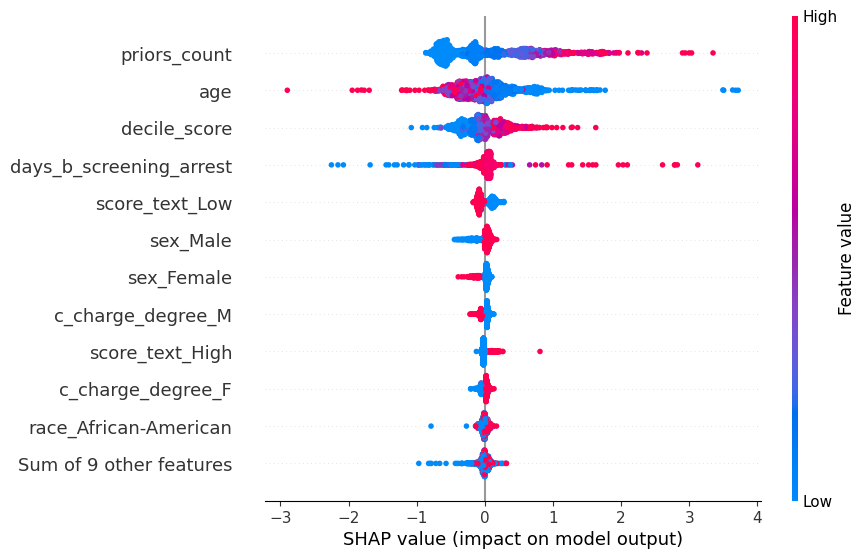


SHAP Waterfall: African-American - Lowest Risk


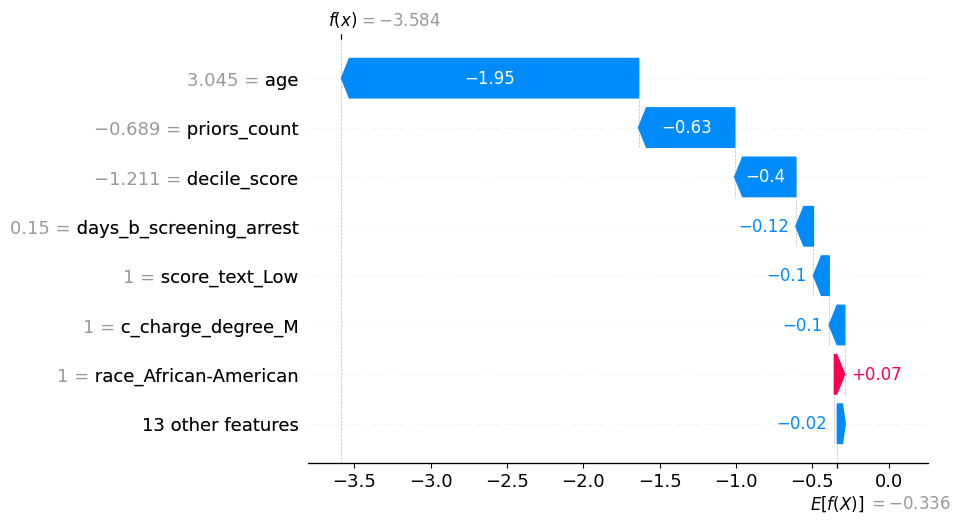


SHAP Waterfall: African-American - Highest Risk


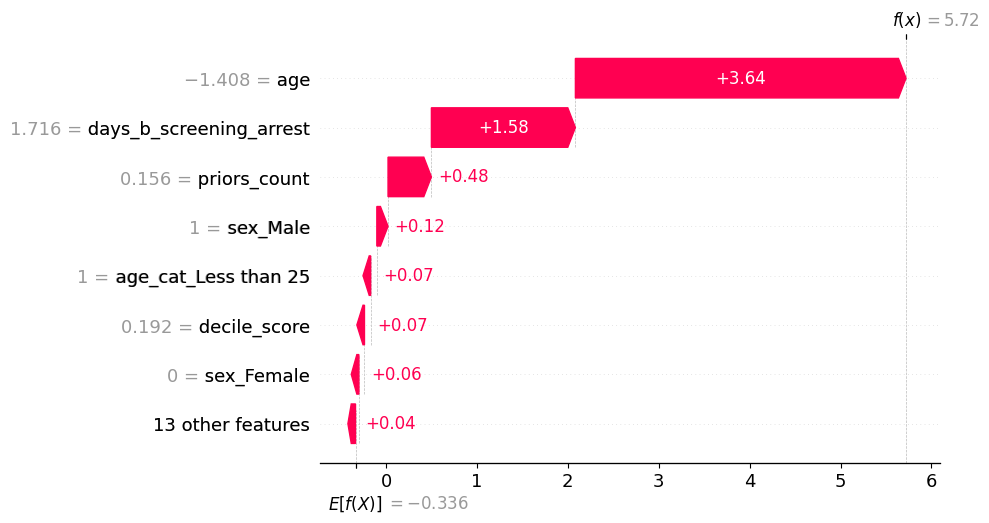


SHAP Waterfall: Caucasian - Lowest Risk


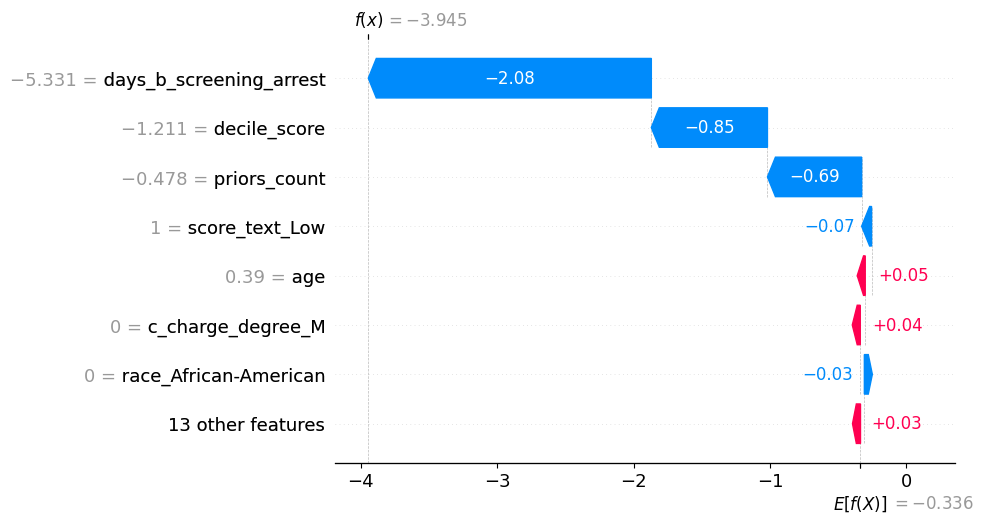


SHAP Waterfall: Caucasian - Highest Risk


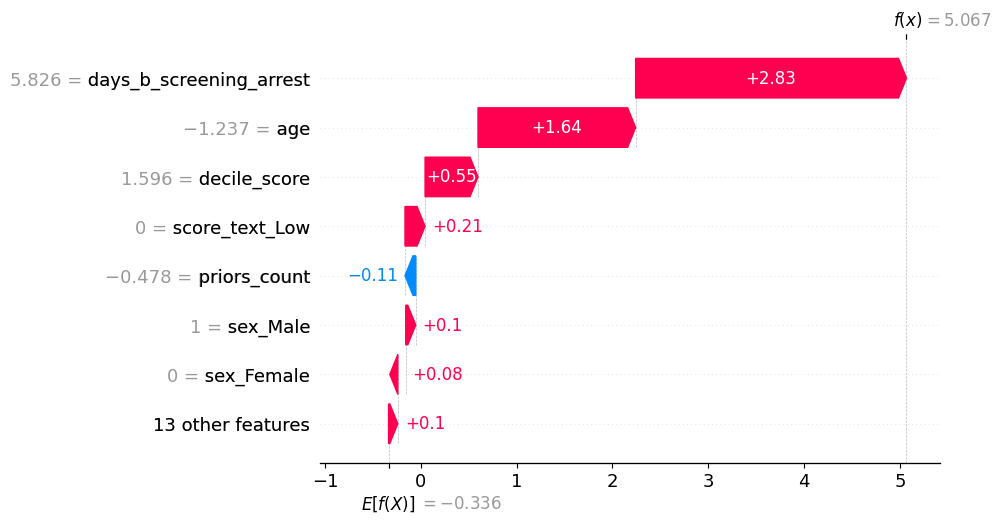

In [33]:
!pip install shap

import shap
import matplotlib.pyplot as plt

fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]
gbt_model = gbt_pipeline.named_steps["classifier"]

X_train_enc = fitted_preprocessor.transform(X_train)
X_test_enc = fitted_preprocessor.transform(X_test)

if hasattr(X_train_enc, "toarray"):
    X_train_enc = X_train_enc.toarray()
if hasattr(X_test_enc, "toarray"):
    X_test_enc = X_test_enc.toarray()

feature_names = (
    numeric_features
    + list(
        fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(category_features)
    )
)

explainer_shap = shap.Explainer(gbt_model, X_train_enc)
shap_values = explainer_shap(X_test_enc, check_additivity=False)
shap_values.feature_names = feature_names

shap.plots.beeswarm(shap_values, max_display=12)

for label, idx in selected_cases:
    loc = X_test.index.get_loc(idx)
    print(f"\nSHAP Waterfall: {label}")
    shap.plots.waterfall(shap_values[loc], max_display=8)



**note**


In this step, I used SHAP to analyze both global and local feature importance.

The beeswarm plot shows the overall importance of features across the test dataset. From this plot, features such as prior offenses and age appear to have the strongest influence on the model’s predictions.

For local explanations, I generated waterfall plots for the four selected individuals. These plots clearly show how each feature contributes to pushing the prediction higher or lower for a specific case.

Compared to LIME, SHAP provides more consistent and theoretically grounded explanations because it is based on Shapley values. The waterfall plots also make it easier to interpret how different features interact to produce the final prediction.

Overall, SHAP provides both global and local insights, making it a powerful tool for understanding model behavior.

Across the four individuals, SHAP consistently highlights priors_count and age-related features as key drivers of predictions. This suggests the model relies on similar patterns across different groups, which supports the consistency of SHAP explanations.

##What does divergence imply for governance?

The divergence between LIME and SHAP implies that relying on a single explanation method may be misleading, so multiple methods should be used in governance and auditing.

# Step 5 — Counterfactual explanations with DiCE for the 4 selected individuals

In [34]:
# STEP 5 — Counterfactuals with DiCE (4 individuals + immutable flag)

!pip install dice-ml -q
import dice_ml
from dice_ml import Dice
import pandas as pd

IMMUTABLE = {"race", "sex"}   # features that should not change

dice_data = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train], axis=1),
    continuous_features=numeric_features,
    outcome_name=target
)

dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

# Run counterfactuals for all 4 selected individuals
for label, idx in selected_cases:
    query = X_test.loc[[idx]]

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=3,
        desired_class="opposite",
        permitted_range={
            "age": [18, 70],
            "priors_count": [0, 38]
        },
        features_to_vary=["age", "priors_count", "c_charge_degree"]
    )

    print(f"\n{'='*70}")
    print(f"DiCE Counterfactuals: {label}")
    print(f"Original predicted probability: {X_test_copy.loc[idx, 'pred_prob']:.3f}")
    print(f"{'='*70}")

    cf_df = cf.cf_examples_list[0].final_cfs_df

    if cf_df is None or len(cf_df) == 0:
        print("No counterfactual found.")
        continue

    # Check whether any immutable feature changed in any counterfactual
    immutable_changed = []
    for feat in IMMUTABLE:
        if feat in cf_df.columns:
            original_val = query[feat].values[0]
            if (cf_df[feat] != original_val).any():
                immutable_changed.append(feat)

    # Report minimal changes using the first counterfactual
    first_cf = cf_df.iloc[0]
    print("\nMinimal feature changes in the first counterfactual:")
    for col in query.columns:
        if str(query.iloc[0][col]) != str(first_cf[col]):
            print(f"- {col}: {query.iloc[0][col]} -> {first_cf[col]}")

    if immutable_changed:
        print(f"\n⚠ Counterfactual requires change in immutable feature(s): {immutable_changed}")
    else:
        print("\nNo immutable features changed.")

    cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  3.32it/s]


DiCE Counterfactuals: African-American - Lowest Risk
Original predicted probability: 0.027

Minimal feature changes in the first counterfactual:
- age: 70 -> 21
- priors_count: 0 -> 25

No immutable features changed.
Query instance (original outcome : 0)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,70,0,-1.0,1,Greater than 45,Male,African-American,M,Low,0



Diverse Counterfactual set (new outcome: 1)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,21,25,-,-,-,-,-,-,-,1
1,32,22,-,-,-,-,-,-,-,1
2,47,36,-,-,-,-,-,-,-,1


...

100%|██████████| 1/1 [00:00<00:00,  4.07it/s]


DiCE Counterfactuals: Caucasian - Highest Risk
Original predicted probability: 0.994

Minimal feature changes in the first counterfactual:
- age: 20 -> 70
- priors_count: 1 -> 4

No immutable features changed.
Query instance (original outcome : 1)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,20,1,28.0,9,Less than 25,Male,Caucasian,F,High,1



Diverse Counterfactual set (new outcome: 0)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,70,4,-,-,-,-,-,-,-,0
1,54,12,-,-,-,-,-,-,-,0
2,57,-,-,-,-,-,-,-,-,0


**note**

In this analysis, race and sex were treated as immutable features and were not allowed to vary during counterfactual generation. Therefore, none of the generated counterfactuals required changes to immutable features.

**note**

In this step, I generated counterfactual explanations using DiCE to understand what minimal changes are needed to flip the model’s prediction for each of the four selected individuals.

For each case, DiCE produces alternative scenarios that would result in a different predicted outcome. The results show that changes in features such as prior offenses, age, and charge type can influence the prediction and potentially reverse the classification.

I also checked whether any counterfactual required changes to immutable features such as race or sex. In this analysis, these features were not allowed to vary, so none of the generated counterfactuals involved changes to immutable attributes.

Overall, counterfactual explanations are useful because they provide actionable insights. However, some suggested changes may not always be realistic in practice, and this highlights the importance of carefully interpreting these results in a real-world context.

The counterfactual results show that relatively small changes in features such as priors_count or charge type can flip the prediction. This suggests the model is sensitive to these variables, but also raises questions about how realistic or achievable these changes are in practice.

## Governance Memo

To: Court Auditor  
Subject: Understanding the COMPAS Replacement Model  

In this analysis, I used LIME, SHAP, and counterfactual explanations to better understand how the model makes predictions and to evaluate its reliability. Each method provides a different perspective, and comparing them helps reveal both useful insights and potential limitations.

The SHAP results provide a consistent global and local understanding of the model. The beeswarm plot shows that features such as prior offenses and age have the strongest influence on predictions across the dataset. The waterfall plots for the four selected individuals further illustrate how each feature contributes to increasing or decreasing the predicted risk score. These explanations are stable and aligned with expectations, making SHAP a reliable tool for interpreting model behavior.

LIME provides local explanations for individual cases. While it highlights similar important features, such as priors and age-related variables, its explanations sometimes differ from SHAP. This is likely because LIME relies on local approximations and random sampling, which can introduce variability. This suggests that LIME explanations should be interpreted cautiously and not used in isolation.

From the group-level evaluation in Step 2, I observed that model performance is not perfectly consistent across racial groups. Differences in metrics such as false positive rate or false negative rate suggest that some groups may be treated less favorably than others. This indicates a potential fairness concern and highlights the importance of monitoring model outcomes across different populations.

Counterfactual explanations generated using DiCE offer a more actionable perspective by showing the minimal changes needed to flip a prediction. For the selected individuals, changes in features such as prior offenses and charge-related variables were often sufficient to alter the outcome. Importantly, immutable features such as race and sex were not allowed to vary in this analysis, and none of the counterfactuals required changes to these attributes. This is important from a fairness and ethical standpoint.

Overall, these results show that transparency alone is not enough to fully trust the model. Different explanation methods may produce different insights, and each has its own limitations. For governance, I recommend regular monitoring of model performance across demographic groups, careful review of feature importance (especially for potential proxy variables), and the use of multiple explanation methods as part of an ongoing audit process. These steps can help ensure that the model remains fair, interpretable, and reliable in practice.
